In [1]:
import sys
import subprocess

# Automatically install nltk if it is missing, same idea as the teacher code.
try:
    import nltk
except ImportError:
    print('NLTK library not found. Installing it now...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'nltk'])
    import nltk

# Importing necessary libraries
import os
import re
import time
import copy
import random
import unicodedata
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from difflib import SequenceMatcher

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

# This keeps CPU training from becoming too slow on a laptop.
if not torch.cuda.is_available():
    torch.set_num_threads(4)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cpu


In [2]:
# Special tokens for sequence boundaries
PAD_token = 0
SOS_token = 1
EOS_token = 2

# Files and folders
data_file = 'vast_english_french.txt'
problem1_split_file = os.path.join('Results_Problem_1', 'problem1_train_val_split.csv')
problem1_summary_file = os.path.join('Results_Problem_1', 'problem1_summary.csv')
results_folder = 'Results_Problem_2'
os.makedirs(results_folder, exist_ok=True)

# Main hyperparameters
# This version is stronger than the first attention run, but still simple.
hidden_size = 160
learning_rate = 0.003
weight_decay = 1e-5
batch_size = 96
dropout_prob = 0.08
n_epochs = 95
max_generation_length = 90
beam_size = 3
decoding_length_factor = 1.25
metric_check_start = 15
metric_check_every = 5
metric_sample_size = 35

# Long-run controls
scheduler_patience = 16
early_stop_patience = 35
min_delta = 0.0002
min_learning_rate = 0.00005

print('hidden_size:', hidden_size)
print('learning_rate:', learning_rate)
print('batch_size:', batch_size)
print('dropout:', dropout_prob)
print('epochs:', n_epochs)
print('beam size:', beam_size)
print('decode length factor:', decoding_length_factor)
print('metric sample size:', metric_sample_size)
print('scheduler patience:', scheduler_patience)
print('early stopping patience:', early_stop_patience)

hidden_size: 160
learning_rate: 0.003
batch_size: 96
dropout: 0.08
epochs: 95
beam size: 3
decode length factor: 1.25
metric sample size: 35
scheduler patience: 16
early stopping patience: 35


In [3]:
def clean_text(text):
    text = unicodedata.normalize('NFC', str(text).strip().lower())
    text = ''.join(ch for ch in text if ch.isprintable())
    text = re.sub(r'([.!?,])', r' \1 ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def read_translation_dataset(filename):
    if not os.path.exists(filename):
        raise FileNotFoundError('Put vast_english_french.txt in the Homework_3 folder and run again.')

    sentence_pairs = []
    with open(filename, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            line = line.strip()
            if line == '':
                continue

            if '\t' in line:
                parts = line.split('\t')
            elif '|||' in line:
                parts = line.split('|||')
            else:
                parts = line.split(',', 1)

            if len(parts) >= 2:
                english = clean_text(parts[0])
                french = clean_text(parts[1])
                if english != '' and french != '':
                    sentence_pairs.append((english, french))

    return sentence_pairs


dataset = read_translation_dataset(data_file)
print('Total pairs in file:', len(dataset))
print('First pair:', dataset[0])

Total pairs in file: 555
First pair: ('i am cold', "j'ai froid")


In [4]:
# Use the exact same split as Problem 1 if it has already been saved.
# The split file is used for which sentences are train/val, but the clean text is pulled
# from the original dataset so weird old cleaning characters do not get learned.
def simple_key(text):
    text = clean_text(text)
    text = re.sub(r'[^a-z0-9]+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

original_dataset = dataset[:]
original_lookup = {simple_key(x[0]): x for x in original_dataset}

if os.path.exists(problem1_split_file):
    old_split_df = pd.read_csv(problem1_split_file)

    train_dataset_pairs = []
    val_dataset_pairs = []

    for _, row in old_split_df.iterrows():
        english_old = str(row['english'])
        french_old = str(row['french'])
        key = simple_key(english_old)

        if key in original_lookup:
            clean_pair = original_lookup[key]
        else:
            clean_pair = (clean_text(english_old), clean_text(french_old))

        if row['split'] == 'train':
            train_dataset_pairs.append(clean_pair)
        else:
            val_dataset_pairs.append(clean_pair)

    dataset = train_dataset_pairs + val_dataset_pairs
    print('Loaded train/validation membership from Problem 1 results.')
else:
    all_indices = list(range(len(dataset)))
    random.Random(seed).shuffle(all_indices)
    split_point = int(0.80 * len(all_indices))
    train_indices = all_indices[:split_point]
    val_indices = all_indices[split_point:]
    train_dataset_pairs = [dataset[i] for i in train_indices]
    val_dataset_pairs = [dataset[i] for i in val_indices]
    print('Problem 1 split file not found, so a seeded 80/20 split was made.')

print('Training pairs:', len(train_dataset_pairs))
print('Validation pairs:', len(val_dataset_pairs))

split_df2 = pd.DataFrame(
    [{'split': 'train', 'english': x[0], 'french': x[1]} for x in train_dataset_pairs] +
    [{'split': 'val', 'english': x[0], 'french': x[1]} for x in val_dataset_pairs]
)
split_df2.to_csv(os.path.join(results_folder, 'problem2_train_val_split.csv'), index=False)
split_df2.head()

Loaded train/validation membership from Problem 1 results.
Training pairs: 444
Validation pairs: 111


,split,english,french
0,train,he teaches world geography to high school classes,il enseigne la géographie mondiale à des class...
1,train,he plays bass guitar in a professional jazz band,il joue de la basse dans un groupe de jazz pro...
2,train,the weather forecast predicts heavy snow tomorrow,les prévisions météo annoncent de fortes chute...
3,train,she loves to wear long flowing cotton skirts,elle adore porter de longues jupes amples en c...
4,train,they listen to the professor with absolute att...,ils écoutent le professeur avec une attention ...


In [5]:
# Step 1: Prepare vocabulary mappings, same basic idea as the teacher code.
unique_chars = sorted(list(set(''.join([word for pair in dataset for word in pair]))))
char_to_index = {'PAD': PAD_token, 'SOS': SOS_token, 'EOS': EOS_token}
for i, char in enumerate(unique_chars):
    char_to_index[char] = i + 3

index_to_char = {i: char for char, i in char_to_index.items()}

print('Vocabulary size:', len(char_to_index))
print('Some characters:', unique_chars[:25])

Vocabulary size: 49
Some characters: [' ', "'", ',', '-', '1', '7', '9', '?', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q']


In [6]:
def sentence_to_indexes(sentence):
    return [char_to_index[char] for char in str(sentence)] + [EOS_token]


def make_batches(data_pairs, batch_size=64, shuffle=True):
    # Simple batch maker. Padding makes training much faster than one sentence at a time.
    data_pairs = data_pairs[:]
    if shuffle:
        random.shuffle(data_pairs)

    for start in range(0, len(data_pairs), batch_size):
        batch_pairs = data_pairs[start:start + batch_size]
        input_list = [sentence_to_indexes(x[0]) for x in batch_pairs]
        target_list = [sentence_to_indexes(x[1]) for x in batch_pairs]

        max_input_len = max(len(x) for x in input_list)
        max_target_len = max(len(x) for x in target_list)

        input_lengths = torch.tensor([len(x) for x in input_list], dtype=torch.long, device=device)
        input_batch = torch.full((len(batch_pairs), max_input_len), PAD_token, dtype=torch.long)
        target_batch = torch.full((len(batch_pairs), max_target_len), PAD_token, dtype=torch.long)

        for i in range(len(batch_pairs)):
            input_batch[i, :len(input_list[i])] = torch.tensor(input_list[i], dtype=torch.long)
            target_batch[i, :len(target_list[i])] = torch.tensor(target_list[i], dtype=torch.long)

        yield input_batch.to(device), target_batch.to(device), input_lengths, batch_pairs

In [7]:
# Step 2: Define the Encoder Model
# Same idea as Problem 1, but bidirectional so attention gets better encoder outputs.
class Encoder(nn.Module):
    def __init__(self, input_size, hidden_size, dropout_prob):
        super(Encoder, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(input_size, hidden_size, padding_idx=PAD_token)
        self.dropout = nn.Dropout(dropout_prob)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True, bidirectional=True)
        self.bridge = nn.Linear(hidden_size * 2, hidden_size)

    def forward(self, input_batch, input_lengths):
        embedded = self.dropout(self.embedding(input_batch))

        # Packing prevents PAD tokens from changing the final hidden state.
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded,
            input_lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )
        packed_outputs, hidden_state = self.gru(packed)
        encoder_outputs, output_lengths = nn.utils.rnn.pad_packed_sequence(packed_outputs, batch_first=True)

        # Combine forward and backward hidden states for the decoder start.
        hidden_cat = torch.cat((hidden_state[-2], hidden_state[-1]), dim=1)
        decoder_start = torch.tanh(self.bridge(hidden_cat)).unsqueeze(0)
        return encoder_outputs, decoder_start

In [8]:
# Step 3: Define the Attention Decoder Model
# This follows the teacher attention.py idea, but uses a batched Luong-style attention.
class AttnDecoder(nn.Module):
    def __init__(self, hidden_size, output_size, dropout_prob):
        super(AttnDecoder, self).__init__()
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.encoder_size = hidden_size * 2
        self.embedding = nn.Embedding(output_size, hidden_size, padding_idx=PAD_token)
        self.dropout = nn.Dropout(dropout_prob)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)

        # Encoder is bidirectional, so project encoder outputs down before dot attention.
        self.encoder_project = nn.Linear(self.encoder_size, hidden_size)
        self.attn_combine = nn.Linear(hidden_size + self.encoder_size, hidden_size)
        self.out = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=2)

    def forward(self, input_batch, hidden_state, encoder_outputs, input_mask):
        embedded = self.dropout(self.embedding(input_batch))
        decoder_outputs, hidden_state = self.gru(embedded, hidden_state)

        projected_encoder = self.encoder_project(encoder_outputs)
        attn_scores = torch.bmm(decoder_outputs, projected_encoder.transpose(1, 2))
        attn_scores = attn_scores.masked_fill(input_mask.unsqueeze(1) == 0, -1000000000.0)
        attn_weights = torch.softmax(attn_scores, dim=2)
        context = torch.bmm(attn_weights, encoder_outputs)

        combined = torch.cat((decoder_outputs, context), dim=2)
        combined = torch.tanh(self.attn_combine(combined))
        output = self.softmax(self.out(combined))
        return output, hidden_state, attn_weights

In [9]:
# Instantiating the models
input_size = len(char_to_index)
output_size = len(char_to_index)

encoder = Encoder(input_size=input_size, hidden_size=hidden_size, dropout_prob=dropout_prob).to(device)
decoder = AttnDecoder(hidden_size=hidden_size, output_size=output_size, dropout_prob=dropout_prob).to(device)

all_model_parameters = list(encoder.parameters()) + list(decoder.parameters())
optimizer = optim.Adam(all_model_parameters, lr=learning_rate, weight_decay=weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=scheduler_patience,
    threshold=min_delta,
    min_lr=min_learning_rate
)
criterion = nn.NLLLoss(ignore_index=PAD_token)


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


print('Encoder parameters:', count_parameters(encoder))
print('Attention Decoder parameters:', count_parameters(decoder))
print('Total parameters:', count_parameters(encoder) + count_parameters(decoder))

Encoder parameters: 368320
Attention Decoder parameters: 298609
Total parameters: 666929


In [10]:
def run_one_epoch(data_pairs, training=True):
    if training:
        encoder.train()
        decoder.train()
    else:
        encoder.eval()
        decoder.eval()

    total_loss = 0.0
    total_batches = 0

    for input_batch, target_batch, input_lengths, batch_pairs in make_batches(data_pairs, batch_size=batch_size, shuffle=training):
        if training:
            optimizer.zero_grad()

        encoder_outputs, encoder_hidden = encoder(input_batch, input_lengths)
        input_mask = torch.arange(encoder_outputs.size(1), device=device).unsqueeze(0) < input_lengths.unsqueeze(1)

        # Teacher forcing: SOS + real previous target characters.
        sos_column = torch.full((target_batch.size(0), 1), SOS_token, dtype=torch.long, device=device)
        decoder_input = torch.cat([sos_column, target_batch[:, :-1]], dim=1)

        decoder_output, decoder_hidden, attn_weights = decoder(decoder_input, encoder_hidden, encoder_outputs, input_mask)
        loss = criterion(decoder_output.reshape(-1, output_size), target_batch.reshape(-1))

        if training:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(all_model_parameters, 1.0)
            optimizer.step()

        total_loss += loss.item()
        total_batches += 1

    return total_loss / total_batches

In [11]:
def quick_predict_sentence(input_string, beam_size=3):
    # Small copy of prediction code used during training to choose a better checkpoint.
    encoder.eval()
    decoder.eval()

    input_string = clean_text(input_string)
    input_indexes = sentence_to_indexes(input_string)
    input_tensor = torch.tensor(input_indexes, dtype=torch.long, device=device).unsqueeze(0)
    input_lengths = torch.tensor([len(input_indexes)], dtype=torch.long, device=device)
    local_max_length = min(max_generation_length, max(12, int(len(input_string) * decoding_length_factor) + 8))

    with torch.no_grad():
        encoder_outputs, encoder_hidden = encoder(input_tensor, input_lengths)
        input_mask = torch.arange(encoder_outputs.size(1), device=device).unsqueeze(0) < input_lengths.unsqueeze(1)
        beams = [([], 0.0, encoder_hidden, torch.tensor([[SOS_token]], dtype=torch.long, device=device), False)]

        for di in range(local_max_length):
            new_beams = []
            for seq, score, hidden_state, decoder_input, done in beams:
                if done:
                    new_beams.append((seq, score, hidden_state, decoder_input, done))
                    continue

                decoder_output, new_hidden, attn_weights = decoder(decoder_input, hidden_state, encoder_outputs, input_mask)
                topv, topi = decoder_output[:, -1, :].topk(beam_size)

                for j in range(beam_size):
                    idx_pred = topi[0, j].item()
                    new_seq = seq + [idx_pred]
                    new_score = score + topv[0, j].item()

                    # Simple repeated-pattern penalty to avoid long repeated phrases.
                    if len(new_seq) >= 6 and new_seq[-3:] == new_seq[-6:-3]:
                        new_score -= 1.2
                    if len(new_seq) >= 8 and new_seq[-4:] == new_seq[-8:-4]:
                        new_score -= 1.5

                    is_done = idx_pred == EOS_token
                    new_input = torch.tensor([[idx_pred]], dtype=torch.long, device=device)
                    new_beams.append((new_seq, new_score, new_hidden, new_input, is_done))

            beams = sorted(new_beams, key=lambda x: x[1] / ((len(x[0]) + 1) ** 0.7), reverse=True)[:beam_size]
            if all(x[4] for x in beams):
                break

    best_seq = beams[0][0]
    predicted_string = ''.join([index_to_char[idx] for idx in best_seq if idx not in (PAD_token, SOS_token, EOS_token)])
    return predicted_string


def quick_validation_score():
    # This is intentionally only a sample so training does not get too slow.
    chencherry = SmoothingFunction()
    sample_pairs = val_dataset_pairs[:metric_sample_size]
    total_bleu = 0.0
    total_similarity = 0.0

    for input_string, target_string in sample_pairs:
        predicted_string = quick_predict_sentence(input_string, beam_size=beam_size)
        total_bleu += sentence_bleu([list(target_string)], list(predicted_string), smoothing_function=chencherry.method1)
        total_similarity += SequenceMatcher(None, target_string, predicted_string).ratio()

    avg_bleu = total_bleu / len(sample_pairs)
    avg_similarity = total_similarity / len(sample_pairs)
    score = avg_bleu + 0.25 * avg_similarity
    return score, avg_bleu, avg_similarity


In [12]:
# Step 4: Core Training Loop
train_losses = []
val_losses = []
lr_history = []
metric_scores = []
metric_bleus = []
metric_similarities = []
metric_epochs = []

best_val_loss = 999999
best_epoch = 0
best_encoder_state = None
best_decoder_state = None

best_metric_score = -1
best_metric_epoch = 0
best_metric_bleu = 0
best_metric_similarity = 0
best_metric_encoder_state = None
best_metric_decoder_state = None

no_improve_count = 0
start_time = time.time()

print('Starting Attention Training...')
for epoch in range(n_epochs):
    avg_train_loss = run_one_epoch(train_dataset_pairs, training=True)

    with torch.no_grad():
        avg_val_loss = run_one_epoch(val_dataset_pairs, training=False)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    scheduler.step(avg_val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    lr_history.append(current_lr)

    if avg_val_loss < best_val_loss - min_delta:
        best_val_loss = avg_val_loss
        best_epoch = epoch
        best_encoder_state = copy.deepcopy(encoder.state_dict())
        best_decoder_state = copy.deepcopy(decoder.state_dict())
        no_improve_count = 0
    else:
        no_improve_count += 1

    # Loss is useful, but the final report cares about generated translations.
    # So every few epochs, save the checkpoint that decodes best on a small validation sample.
    if epoch >= metric_check_start and epoch % metric_check_every == 0:
        metric_score, metric_bleu, metric_similarity = quick_validation_score()
        metric_epochs.append(epoch)
        metric_scores.append(metric_score)
        metric_bleus.append(metric_bleu)
        metric_similarities.append(metric_similarity)

        if metric_score > best_metric_score:
            best_metric_score = metric_score
            best_metric_epoch = epoch
            best_metric_bleu = metric_bleu
            best_metric_similarity = metric_similarity
            best_metric_encoder_state = copy.deepcopy(encoder.state_dict())
            best_metric_decoder_state = copy.deepcopy(decoder.state_dict())

        print(f'Epoch {epoch:03d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Sample BLEU: {metric_bleu:.4f} | Sample Sim: {metric_similarity:.4f} | LR: {current_lr:.6f}')
    elif epoch % 10 == 0 or epoch == n_epochs - 1:
        print(f'Epoch {epoch:03d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | LR: {current_lr:.6f} | No Improve: {no_improve_count}')

    if no_improve_count >= early_stop_patience:
        print('Early stopping reached at epoch:', epoch)
        break

training_time = time.time() - start_time
actual_epochs = len(train_losses)

# Prefer the best generated-translation checkpoint. If it was never evaluated, fall back to best loss.
if best_metric_encoder_state is not None:
    encoder.load_state_dict(best_metric_encoder_state)
    decoder.load_state_dict(best_metric_decoder_state)
    final_checkpoint_type = 'best sampled BLEU/similarity checkpoint'
else:
    encoder.load_state_dict(best_encoder_state)
    decoder.load_state_dict(best_decoder_state)
    final_checkpoint_type = 'best validation-loss checkpoint'

print('Training time:', round(training_time, 2), 'seconds')
print('Epochs actually run:', actual_epochs)
print('Best validation-loss epoch:', best_epoch)
print('Best validation loss:', round(best_val_loss, 4))
print('Final checkpoint used:', final_checkpoint_type)
print('Best metric epoch:', best_metric_epoch)
print('Best sampled BLEU:', round(best_metric_bleu, 4))
print('Best sampled similarity:', round(best_metric_similarity, 4))


Starting Attention Training...
Epoch 000 | Train Loss: 3.2731 | Val Loss: 2.8709 | LR: 0.003000 | No Improve: 0
Epoch 010 | Train Loss: 1.7224 | Val Loss: 1.8110 | LR: 0.003000 | No Improve: 0
Epoch 015 | Train Loss: 1.3981 | Val Loss: 1.6141 | Sample BLEU: 0.1466 | Sample Sim: 0.3966 | LR: 0.003000
Epoch 020 | Train Loss: 1.1131 | Val Loss: 1.5200 | Sample BLEU: 0.1563 | Sample Sim: 0.3863 | LR: 0.003000
Epoch 025 | Train Loss: 0.8649 | Val Loss: 1.4486 | Sample BLEU: 0.2273 | Sample Sim: 0.4404 | LR: 0.003000
Epoch 030 | Train Loss: 0.6467 | Val Loss: 1.4623 | Sample BLEU: 0.2231 | Sample Sim: 0.4509 | LR: 0.003000
Epoch 035 | Train Loss: 0.4966 | Val Loss: 1.5088 | Sample BLEU: 0.2601 | Sample Sim: 0.4757 | LR: 0.003000
Epoch 040 | Train Loss: 0.3863 | Val Loss: 1.5941 | Sample BLEU: 0.2512 | Sample Sim: 0.4544 | LR: 0.003000
Epoch 045 | Train Loss: 0.2908 | Val Loss: 1.6229 | Sample BLEU: 0.2573 | Sample Sim: 0.4688 | LR: 0.003000
Epoch 050 | Train Loss: 0.1998 | Val Loss: 1.6389 |

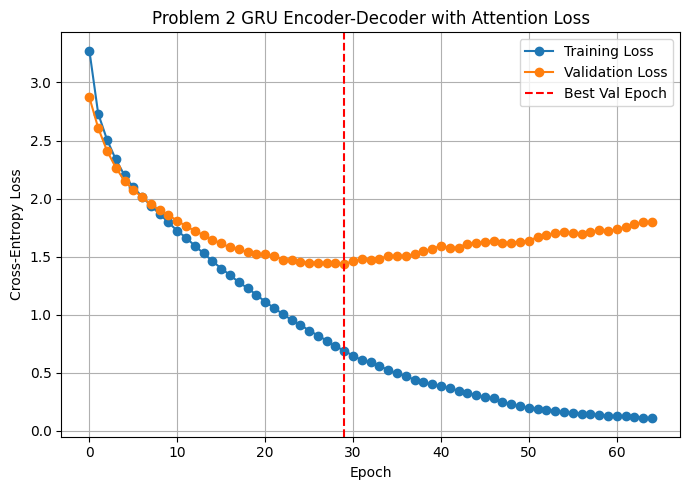

,epoch,sample_metric_score,sample_char_bleu4,sample_sequence_similarity
5,40,0.364794,0.251204,0.454363
6,45,0.374540,0.257339,0.468803
7,50,0.387006,0.269428,0.470311
8,55,0.399142,0.274397,0.498979
9,60,0.390535,0.267119,0.493667


In [13]:
# Evaluation curves required by the homework
plt.figure(figsize=(7, 5))
plt.plot(train_losses, marker='o', label='Training Loss')
plt.plot(val_losses, marker='o', label='Validation Loss')
plt.axvline(best_epoch, color='red', linestyle='--', label='Best Val Epoch')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('Problem 2 GRU Encoder-Decoder with Attention Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(results_folder, 'problem2_loss_curve.png'), dpi=200, bbox_inches='tight')
plt.show()

history_df = pd.DataFrame({
    'epoch': list(range(len(train_losses))),
    'train_loss': train_losses,
    'validation_loss': val_losses,
    'learning_rate': lr_history
})
history_df.to_csv(os.path.join(results_folder, 'problem2_training_history.csv'), index=False)
history_df.head()

metric_history_df = pd.DataFrame({
    'epoch': metric_epochs,
    'sample_metric_score': metric_scores,
    'sample_char_bleu4': metric_bleus,
    'sample_sequence_similarity': metric_similarities
})
metric_history_df.to_csv(os.path.join(results_folder, 'problem2_metric_history.csv'), index=False)
metric_history_df.tail()


In [14]:
def predict_sentence(input_string, return_attention=False, beam_size=3):
    encoder.eval()
    decoder.eval()

    input_string = clean_text(input_string)
    input_indexes = sentence_to_indexes(input_string)
    input_tensor = torch.tensor(input_indexes, dtype=torch.long, device=device).unsqueeze(0)
    input_lengths = torch.tensor([len(input_indexes)], dtype=torch.long, device=device)

    # Shorter max length helps avoid repeated-sentence loops.
    local_max_length = min(max_generation_length, max(12, int(len(input_string) * decoding_length_factor) + 8))

    with torch.no_grad():
        encoder_outputs, encoder_hidden = encoder(input_tensor, input_lengths)
        input_mask = torch.arange(encoder_outputs.size(1), device=device).unsqueeze(0) < input_lengths.unsqueeze(1)

        # Greedy decoding is used for attention maps because it is easier to visualize.
        if return_attention or beam_size <= 1:
            decoder_hidden = encoder_hidden
            decoder_input = torch.tensor([[SOS_token]], dtype=torch.long, device=device)
            predicted_indices = []
            attention_rows = []

            for di in range(local_max_length):
                decoder_output, decoder_hidden, attn_weights = decoder(decoder_input, decoder_hidden, encoder_outputs, input_mask)
                topv, topi = decoder_output[:, -1, :].topk(1)
                idx_pred = topi.item()

                attention_rows.append(attn_weights[0, -1, :len(input_indexes)].detach().cpu().numpy())

                if idx_pred == EOS_token:
                    break

                if idx_pred not in (PAD_token, SOS_token):
                    predicted_indices.append(idx_pred)

                decoder_input = torch.tensor([[idx_pred]], dtype=torch.long, device=device)

            predicted_string = ''.join([index_to_char[idx] for idx in predicted_indices])

            if return_attention:
                attention_matrix = np.array(attention_rows)
                source_chars = [index_to_char[idx] for idx in input_indexes if idx != EOS_token]
                predicted_chars = [index_to_char[idx] for idx in predicted_indices]
                return predicted_string, attention_matrix, source_chars, predicted_chars

            return predicted_string

        # Beam search usually avoids some bad early greedy choices.
        beams = [([], 0.0, encoder_hidden, torch.tensor([[SOS_token]], dtype=torch.long, device=device), False)]

        for di in range(local_max_length):
            new_beams = []
            for seq, score, hidden_state, decoder_input, done in beams:
                if done:
                    new_beams.append((seq, score, hidden_state, decoder_input, done))
                    continue

                decoder_output, new_hidden, attn_weights = decoder(decoder_input, hidden_state, encoder_outputs, input_mask)
                topv, topi = decoder_output[:, -1, :].topk(beam_size)

                for j in range(beam_size):
                    idx_pred = topi[0, j].item()
                    new_score = score + topv[0, j].item()
                    new_seq = seq + [idx_pred]

                    # Simple repeated-pattern penalty to avoid long repeated phrases.
                    if len(new_seq) >= 6 and new_seq[-3:] == new_seq[-6:-3]:
                        new_score -= 1.2
                    if len(new_seq) >= 8 and new_seq[-4:] == new_seq[-8:-4]:
                        new_score -= 1.5

                    is_done = idx_pred == EOS_token
                    new_input = torch.tensor([[idx_pred]], dtype=torch.long, device=device)
                    new_beams.append((new_seq, new_score, new_hidden, new_input, is_done))

            # Length normalization keeps the model from always choosing very short strings.
            beams = sorted(new_beams, key=lambda x: x[1] / ((len(x[0]) + 1) ** 0.7), reverse=True)[:beam_size]
            if all(x[4] for x in beams):
                break

        best_seq = beams[0][0]
        predicted_string = ''.join([index_to_char[idx] for idx in best_seq if idx not in (PAD_token, SOS_token, EOS_token)])
        return predicted_string


def character_accuracy(target_string, predicted_string):
    if len(target_string) == 0 and len(predicted_string) == 0:
        return 1.0

    max_len = max(len(target_string), len(predicted_string))
    correct_chars = 0
    for i in range(max_len):
        if i < len(target_string) and i < len(predicted_string):
            if target_string[i] == predicted_string[i]:
                correct_chars += 1
    return correct_chars / max_len


def sequence_similarity(target_string, predicted_string):
    return SequenceMatcher(None, target_string, predicted_string).ratio()

In [15]:
# Step 5: Evaluation: exact sentence accuracy and BLEU-4
encoder.eval()
decoder.eval()

correct_exact_matches = 0
total_char_bleu_score = 0.0
total_word_bleu_score = 0.0
total_char_accuracy = 0.0
total_sequence_similarity = 0.0
chencherry = SmoothingFunction()
rows = []

print('--- Generating Attention Evaluation Examples ---')
for i, (input_string, target_string) in enumerate(val_dataset_pairs):
    predicted_string = predict_sentence(input_string, beam_size=beam_size)

    if predicted_string == target_string:
        correct_exact_matches += 1

    char_bleu = sentence_bleu([list(target_string)], list(predicted_string), smoothing_function=chencherry.method1)
    word_bleu = sentence_bleu([target_string.split()], predicted_string.split(), smoothing_function=chencherry.method1)
    char_acc = character_accuracy(target_string, predicted_string)
    seq_sim = sequence_similarity(target_string, predicted_string)

    total_char_bleu_score += char_bleu
    total_word_bleu_score += word_bleu
    total_char_accuracy += char_acc
    total_sequence_similarity += seq_sim

    match_status = 'PASS' if predicted_string == target_string else 'FAIL'
    rows.append({
        'input_english': input_string,
        'target_french': target_string,
        'predicted_french': predicted_string,
        'exact_match': match_status,
        'char_accuracy': char_acc,
        'sequence_similarity': seq_sim,
        'char_bleu4': char_bleu,
        'word_bleu4': word_bleu
    })

    if i < 5:
        print(f'Input: {input_string:<38} | Target: {target_string:<38} | Predicted: {predicted_string:<38} | Match: {match_status:<4} | Char BLEU: {char_bleu:.4f}')

final_exact_accuracy = correct_exact_matches / len(val_dataset_pairs)
average_char_bleu = total_char_bleu_score / len(val_dataset_pairs)
average_word_bleu = total_word_bleu_score / len(val_dataset_pairs)
average_char_accuracy = total_char_accuracy / len(val_dataset_pairs)
average_sequence_similarity = total_sequence_similarity / len(val_dataset_pairs)

print('--------------------------------------------------------------------------------')
print('Final Global Metrics across Validation Set:')
print(f' -> Traditional Exact-Match Accuracy : {final_exact_accuracy * 100:.2f}% ({correct_exact_matches}/{len(val_dataset_pairs)} samples)')
print(f' -> Average Character Accuracy       : {average_char_accuracy * 100:.2f}%')
print(f' -> Average Sequence Similarity      : {average_sequence_similarity * 100:.2f}%')
print(f' -> Average Character BLEU-4 Score   : {average_char_bleu:.4f}')
print(f' -> Average Word BLEU-4 Score        : {average_word_bleu:.4f}')

results_df = pd.DataFrame(rows)
results_df.to_csv(os.path.join(results_folder, 'problem2_validation_results.csv'), index=False)
results_df.head()

--- Generating Attention Evaluation Examples ---
Input: they feed the pigeons in the square    | Target: ils nourrissent les pigeons sur la place | Predicted: ils nourrissent les excentre été       | Match: FAIL | Char BLEU: 0.5103
Input: she practices yoga every morning       | Target: elle pratique le yoga tous les matins  | Predicted: elle joue d'un chaque jour             | Match: FAIL | Char BLEU: 0.1879
Input: i enjoy walking in the snow            | Target: j'aime marcher dans la neige           | Predicted: j'aime marcher dans la pluie           | Match: FAIL | Char BLEU: 0.8280
Input: she loves to wear modern jackets       | Target: elle adore porter des vestes modernes  | Predicted: elle adore porter des conserdi         | Match: FAIL | Char BLEU: 0.6116
Input: the city bus arrives precisely at five o'clock | Target: le bus de la ville arrive précisément à cinq heures | Predicted: le bus arrive à cinq heurse            | Match: FAIL | Char BLEU: 0.3590
-----------------------

,input_english,target_french,predicted_french,exact_match,char_accuracy,sequence_similarity,char_bleu4,word_bleu4
0,they feed the pigeons in the square,ils nourrissent les pigeons sur la place,ils nourrissent les excentre été,FAIL,0.525000,0.638889,0.510329,0.178248
1,she practices yoga every morning,elle pratique le yoga tous les matins,elle joue d'un chaque jour,FAIL,0.216216,0.380952,0.187909,0.036015
2,i enjoy walking in the snow,j'aime marcher dans la neige,j'aime marcher dans la pluie,FAIL,0.857143,0.857143,0.828026,0.668740
3,she loves to wear modern jackets,elle adore porter des vestes modernes,elle adore porter des conserdi,FAIL,0.621622,0.746269,0.611639,0.547518
4,the city bus arrives precisely at five o'clock,le bus de la ville arrive précisément à cinq h...,le bus arrive à cinq heurse,FAIL,0.137255,0.666667,0.359009,0.066282


In [16]:
# Teacher-style training-set check
# This is not the main homework metric, but it helps compare with the teacher examples.
train_correct = 0
train_char_bleu_total = 0.0
train_char_acc_total = 0.0

for input_string, target_string in train_dataset_pairs:
    predicted_string = predict_sentence(input_string, beam_size=1)

    if predicted_string == target_string:
        train_correct += 1

    train_char_bleu_total += sentence_bleu([list(target_string)], list(predicted_string), smoothing_function=SmoothingFunction().method1)
    train_char_acc_total += character_accuracy(target_string, predicted_string)

teacher_style_train_accuracy = train_correct / len(train_dataset_pairs)
teacher_style_train_bleu = train_char_bleu_total / len(train_dataset_pairs)
teacher_style_train_char_accuracy = train_char_acc_total / len(train_dataset_pairs)

print('Teacher-style Training Exact Accuracy:', round(teacher_style_train_accuracy * 100, 2), '%')
print('Teacher-style Training Character Accuracy:', round(teacher_style_train_char_accuracy * 100, 2), '%')
print('Teacher-style Training BLEU-4:', round(teacher_style_train_bleu, 4))

Teacher-style Training Exact Accuracy: 52.48 %
Teacher-style Training Character Accuracy: 77.44 %
Teacher-style Training BLEU-4: 0.8176


In [17]:
# Save a small summary table for the report
summary_df = pd.DataFrame([{
    'model': 'GRU Encoder-Decoder with Attention',
    'direction': 'English to French',
    'seed': seed,
    'train_size': len(train_dataset_pairs),
    'validation_size': len(val_dataset_pairs),
    'hidden_size': hidden_size,
    'dropout_prob': dropout_prob,
    'beam_size': beam_size,
    'decoding_length_factor': decoding_length_factor,
    'final_checkpoint_type': final_checkpoint_type,
    'best_metric_epoch': best_metric_epoch,
    'best_sampled_bleu4': best_metric_bleu,
    'best_sampled_similarity': best_metric_similarity,
    'starting_learning_rate': learning_rate,
    'final_learning_rate': optimizer.param_groups[0]['lr'],
    'weight_decay': weight_decay,
    'batch_size': batch_size,
    'max_epochs': n_epochs,
    'epochs_run': actual_epochs,
    'scheduler_patience': scheduler_patience,
    'early_stop_patience': early_stop_patience,
    'best_epoch': best_epoch,
    'final_train_loss': train_losses[-1],
    'final_validation_loss': val_losses[-1],
    'best_validation_loss': best_val_loss,
    'traditional_sequence_accuracy': final_exact_accuracy,
    'validation_character_accuracy': average_char_accuracy,
    'validation_sequence_similarity': average_sequence_similarity,
    'validation_bleu4_char_level': average_char_bleu,
    'validation_bleu4_word_level': average_word_bleu,
    'teacher_style_train_accuracy': teacher_style_train_accuracy,
    'teacher_style_train_char_accuracy': teacher_style_train_char_accuracy,
    'teacher_style_train_bleu4': teacher_style_train_bleu,
    'training_time_sec': training_time,
    'encoder_params': count_parameters(encoder),
    'decoder_params': count_parameters(decoder),
    'total_params': count_parameters(encoder) + count_parameters(decoder),
    'hardware': str(device)
}])

summary_df.to_csv(os.path.join(results_folder, 'problem2_summary.csv'), index=False)
summary_df

,model,direction,seed,train_size,validation_size,hidden_size,dropout_prob,beam_size,decoding_length_factor,final_checkpoint_type,...,validation_bleu4_char_level,validation_bleu4_word_level,teacher_style_train_accuracy,teacher_style_train_char_accuracy,teacher_style_train_bleu4,training_time_sec,encoder_params,decoder_params,total_params,hardware
0,GRU Encoder-Decoder with Attention,English to French,42,444,111,160,0.08,3,1.25,best sampled BLEU/similarity checkpoint,...,0.262004,0.089938,0.524775,0.774447,0.817552,259.54916,368320,298609,666929,cpu


In [18]:
# Save 5 qualitative examples for the report
sample_df = results_df.head(5)
sample_df.to_csv(os.path.join(results_folder, 'problem2_sample_translations.csv'), index=False)
sample_df

,input_english,target_french,predicted_french,exact_match,char_accuracy,sequence_similarity,char_bleu4,word_bleu4
0,they feed the pigeons in the square,ils nourrissent les pigeons sur la place,ils nourrissent les excentre été,FAIL,0.525000,0.638889,0.510329,0.178248
1,she practices yoga every morning,elle pratique le yoga tous les matins,elle joue d'un chaque jour,FAIL,0.216216,0.380952,0.187909,0.036015
2,i enjoy walking in the snow,j'aime marcher dans la neige,j'aime marcher dans la pluie,FAIL,0.857143,0.857143,0.828026,0.668740
3,she loves to wear modern jackets,elle adore porter des vestes modernes,elle adore porter des conserdi,FAIL,0.621622,0.746269,0.611639,0.547518
4,the city bus arrives precisely at five o'clock,le bus de la ville arrive précisément à cinq h...,le bus arrive à cinq heurse,FAIL,0.137255,0.666667,0.359009,0.066282


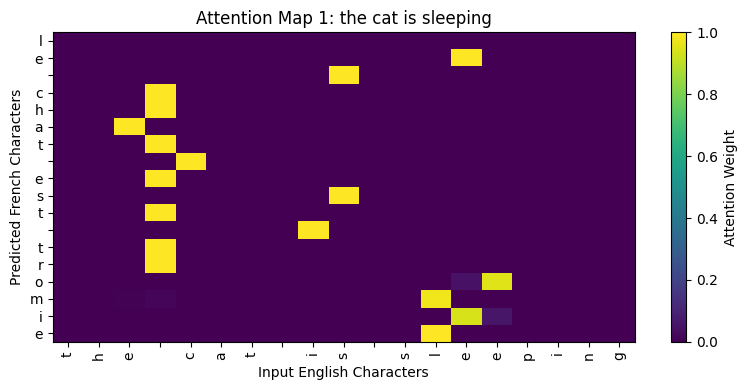

Input: the cat is sleeping
Target: le chat dort
Predicted: le chat est tromie
Saved: Results_Problem_2\problem2_attention_map_1.png


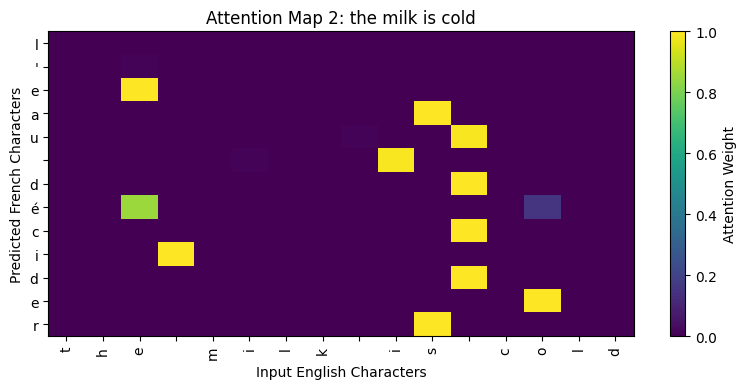

Input: the milk is cold
Target: le lait est froid
Predicted: l'eau décider
Saved: Results_Problem_2\problem2_attention_map_2.png


In [19]:
# Attention map visualizations for the report
# Shorter sentences are easier to read in an attention heatmap.
short_examples = sorted(val_dataset_pairs, key=lambda x: len(x[0]) + len(x[1]))[:2]

for map_num, (input_string, target_string) in enumerate(short_examples, start=1):
    predicted_string, attention_matrix, source_chars, predicted_chars = predict_sentence(input_string, return_attention=True)

    if len(predicted_chars) == 0:
        predicted_chars = [' ']
        attention_matrix = np.zeros((1, len(source_chars)))

    plt.figure(figsize=(max(8, len(source_chars) * 0.35), max(4, len(predicted_chars) * 0.18)))
    plt.imshow(attention_matrix[:len(predicted_chars), :len(source_chars)], aspect='auto', cmap='viridis')
    plt.colorbar(label='Attention Weight')
    plt.xticks(range(len(source_chars)), source_chars, rotation=90)
    plt.yticks(range(len(predicted_chars)), predicted_chars)
    plt.xlabel('Input English Characters')
    plt.ylabel('Predicted French Characters')
    plt.title('Attention Map ' + str(map_num) + ': ' + input_string)
    plt.tight_layout()
    out_file = os.path.join(results_folder, 'problem2_attention_map_' + str(map_num) + '.png')
    plt.savefig(out_file, dpi=200, bbox_inches='tight')
    plt.show()

    print('Input:', input_string)
    print('Target:', target_string)
    print('Predicted:', predicted_string)
    print('Saved:', out_file)

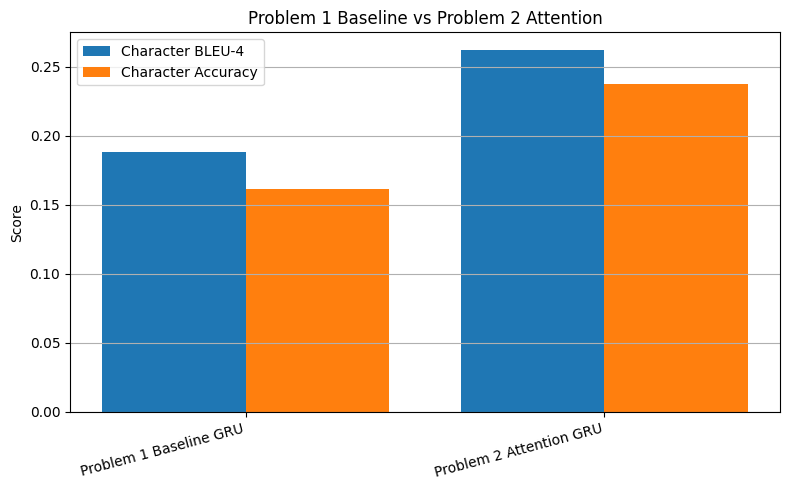

,model,exact_accuracy,char_accuracy,sequence_similarity,char_bleu4,word_bleu4,best_validation_loss,training_time_sec,total_params
0,Problem 1 Baseline GRU,0.000000,0.161757,NaN,0.188116,0.050088,1.411489,61.77148,332208
1,Problem 2 Attention GRU,0.009009,0.237327,0.489935,0.262004,0.089938,1.435507,259.54916,666929


In [20]:
# Problem 1 vs Problem 2 comparison table and plot
comparison_rows = []

if os.path.exists(problem1_summary_file):
    p1 = pd.read_csv(problem1_summary_file).iloc[0].to_dict()
    comparison_rows.append({
        'model': 'Problem 1 Baseline GRU',
        'exact_accuracy': p1.get('traditional_sequence_accuracy', np.nan),
        'char_accuracy': p1.get('validation_character_accuracy', np.nan),
        'sequence_similarity': p1.get('validation_sequence_similarity', np.nan),
        'char_bleu4': p1.get('validation_bleu4_char_level', np.nan),
        'word_bleu4': p1.get('validation_bleu4_word_level', np.nan),
        'best_validation_loss': p1.get('best_validation_loss', np.nan),
        'training_time_sec': p1.get('training_time_sec', np.nan),
        'total_params': p1.get('total_params', np.nan)
    })

comparison_rows.append({
    'model': 'Problem 2 Attention GRU',
    'exact_accuracy': final_exact_accuracy,
    'char_accuracy': average_char_accuracy,
    'sequence_similarity': average_sequence_similarity,
    'char_bleu4': average_char_bleu,
    'word_bleu4': average_word_bleu,
    'best_validation_loss': best_val_loss,
    'training_time_sec': training_time,
    'total_params': count_parameters(encoder) + count_parameters(decoder)
})

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv(os.path.join(results_folder, 'problem1_vs_problem2_comparison.csv'), index=False)

if len(comparison_df) > 1:
    plt.figure(figsize=(8, 5))
    x = np.arange(len(comparison_df))
    plt.bar(x - 0.2, comparison_df['char_bleu4'], width=0.4, label='Character BLEU-4')
    plt.bar(x + 0.2, comparison_df['char_accuracy'], width=0.4, label='Character Accuracy')
    plt.xticks(x, comparison_df['model'], rotation=15, ha='right')
    plt.ylabel('Score')
    plt.title('Problem 1 Baseline vs Problem 2 Attention')
    plt.legend()
    plt.grid(axis='y')
    plt.tight_layout()
    plt.savefig(os.path.join(results_folder, 'problem1_vs_problem2_comparison.png'), dpi=200, bbox_inches='tight')
    plt.show()

comparison_df

## Notes for the Report

Attention should help because the decoder is no longer forced to compress the whole English sentence into only one final hidden state. Each predicted French character can look back at different English characters.

Exact sentence accuracy can still stay low even when BLEU improves. Exact accuracy requires the whole generated sentence to match perfectly. BLEU gives partial credit when the model gets many correct character/word chunks but misses accents, endings, word order, or one phrase.